In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.cluster import KMeans,DBSCAN
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('EastWestAirline.csv')
df.tail()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0
3998,4021,3016,0,1,1,1,0,0,0,0,1398,0


In [3]:
df.shape

(3999, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe().sum()

ID#                  1.724358e+04
Balance              2.037242e+06
Qual_miles           1.606478e+04
cc1_miles            4.013436e+03
cc2_miles            4.007162e+03
cc3_miles            4.009207e+03
Bonus_miles          3.412013e+05
Bonus_trans          4.138206e+03
Flight_miles_12mo    3.698726e+04
Flight_trans_12      4.058167e+03
Days_since_enroll    3.069719e+04
Award?               4.001853e+03
dtype: float64

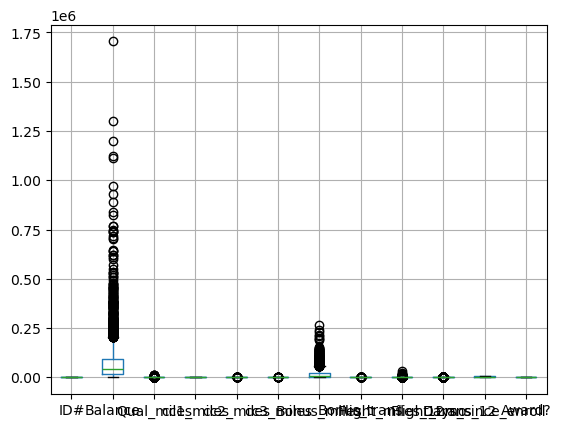

In [8]:
df.boxplot()
plt.show()

In [9]:
#### outlier capping
def outiler_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x:Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outiler_capping(df,col)

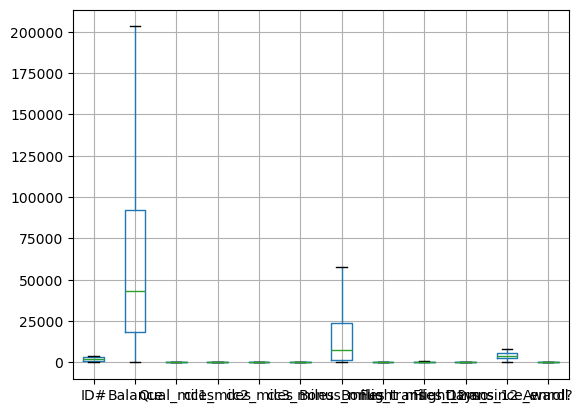

In [10]:
df.boxplot()
plt.show()

In [11]:
### Standard Scaler
std_sca  = StandardScaler()
df1 = pd.DataFrame(std_sca.fit_transform(df),columns=df.columns)

In [12]:
df1.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-1.735125,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919
1,-1.734263,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919
2,-1.733402,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919
3,-1.732540,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919
4,-1.731679,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918


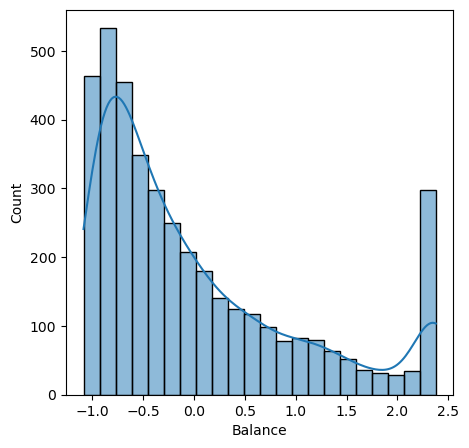

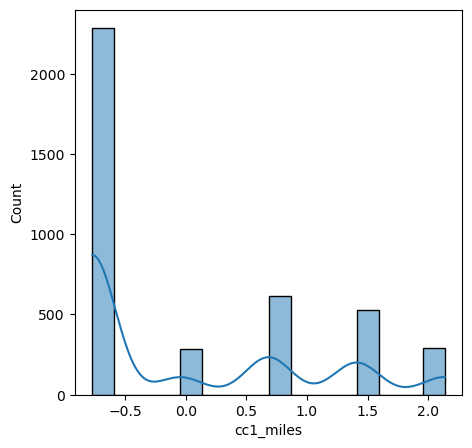

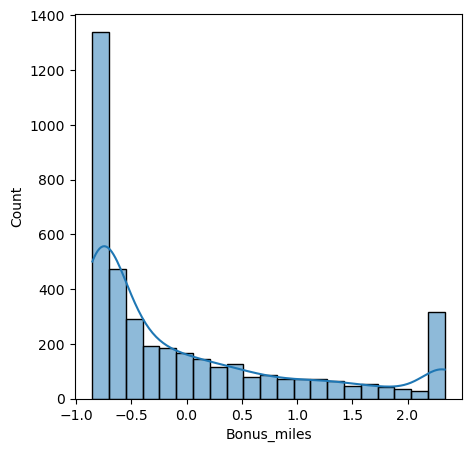

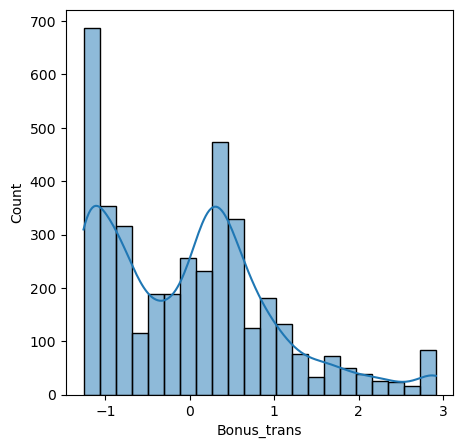

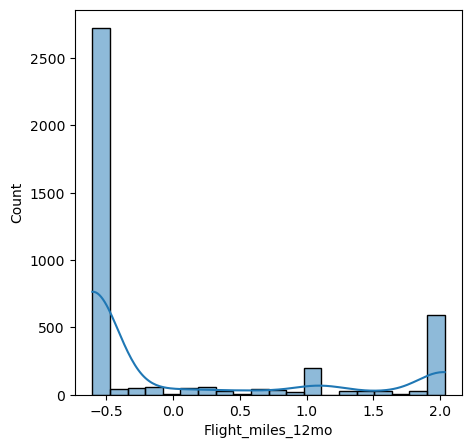

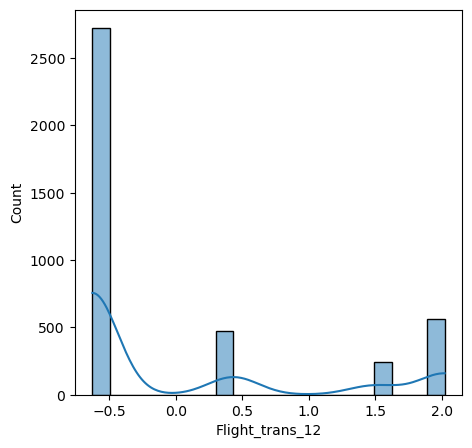

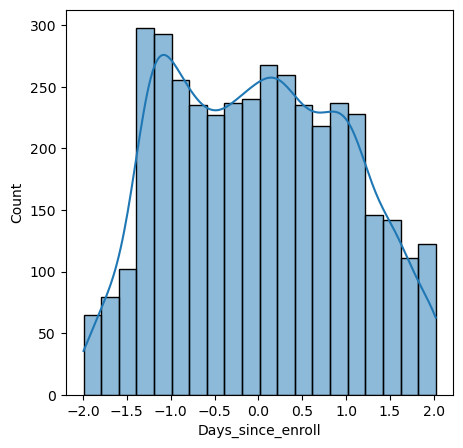

In [13]:
### Data visualization 
for i in ['Balance','cc1_miles','Bonus_miles','Bonus_trans','Flight_miles_12mo','Flight_trans_12','Days_since_enroll']:
    plt.figure(figsize = (5,5))
    sns.histplot(x = df1[i],kde = True)
    plt.show()

In [14]:
kmean = KMeans(n_clusters=4)
clusters = kmean.fit(df1)

In [15]:
np.unique(clusters.labels_)

array([0, 1, 2, 3], dtype=int32)

In [22]:
df1['clusters'] = clusters.labels_
df1[df.clusters == 2].head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,clusters
1129,-0.752891,-1.059272,0.0,-0.769578,0.0,0.0,-0.776636,-0.819689,-0.604313,-0.626143,-1.245382,-0.766919,4,2
1424,-0.496993,-0.710384,0.0,0.683121,0.0,0.0,-0.030639,-0.051637,0.074478,0.432384,-0.741720,-0.766919,4,2
1950,-0.041202,-0.819765,0.0,-0.769578,0.0,0.0,-0.852718,-1.258576,-0.604313,-0.626143,-0.455504,-0.766919,4,2
1952,-0.039478,-0.393644,0.0,-0.769578,0.0,0.0,-0.774533,-0.271080,-0.604313,-0.626143,-0.592558,-0.766919,4,2
1953,-0.038617,-0.953283,0.0,-0.769578,0.0,0.0,-0.819519,-1.039133,1.432062,1.490912,-0.271958,-0.766919,0,2


In [23]:
km_model = KMeans(n_clusters=5, random_state=42)
df1['KMeans_Cluster'] = km_model.fit_predict(df1)

In [27]:
### Kmean
kmean = KMeans(n_clusters=3)
clusters = kmean.fit(df)
silhouette_score(df1,clusters.labels_)

0.09653709163692561

In [29]:
df1.drop(columns=['Qual_miles','cc2_miles','cc3_miles','Bonus_miles','Bonus_trans','Flight_miles_12mo','Flight_trans_12'],inplace = True)
df1.head()

,ID#,Balance,cc1_miles,Days_since_enroll,Award?,KMeans_Cluster,clusters
0,-1.735125,-0.607258,-0.769578,1.395454,-0.766919,2,0
1,-1.734263,-0.758947,-0.769578,1.379957,-0.766919,2,0
2,-1.733402,-0.382070,-0.769578,1.411920,-0.766919,2,0
3,-1.732540,-0.835106,-0.769578,1.372208,-0.766919,2,0
4,-1.731679,0.579265,1.409471,1.363975,1.303918,3,1


In [30]:
### Silhouette score
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [31]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df1)

In [32]:
best_score = -1
best_k = None

In [65]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df1)
    score = silhouette_score(df1, labels)
    print(f"K={k}, Silhouette={score:.3f}")
    if score > best_score:
        best_score = score
        best_k = k

K=2, Silhouette=0.650
K=3, Silhouette=0.623
K=4, Silhouette=0.532
K=5, Silhouette=0.556
K=6, Silhouette=0.603
K=7, Silhouette=0.605
K=8, Silhouette=0.590
K=9, Silhouette=0.566
K=10, Silhouette=0.500


In [66]:
kmeans = KMeans(n_clusters=4)
cluster = kmeans.fit(df1)
silhouette_score(df1,cluster.labels_)

0.5315104777865614

In [28]:
kmean.inertia_

2442738934904.7783

In [67]:
sse = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df1)
    sse.append(km.inertia_)

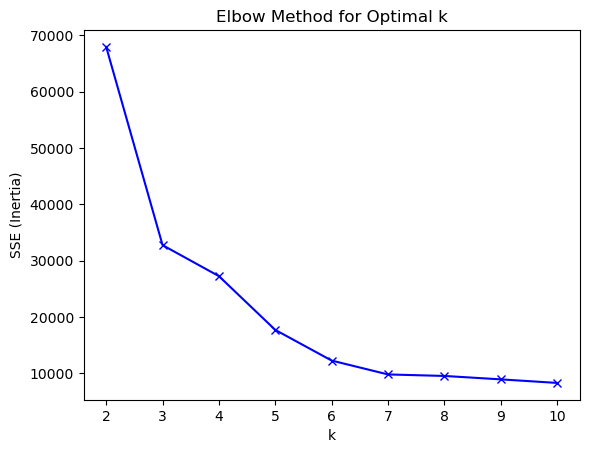

In [68]:
plt.plot(K, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [39]:
km_model = KMeans(n_clusters=5, random_state=42)
df1['KMeans_Cluster'] = km_model.fit_predict(df1)

In [40]:
from scipy.cluster.hierarchy import linkage,fcluster,dendrogram
linkage_matrix = linkage(df1, method='ward')

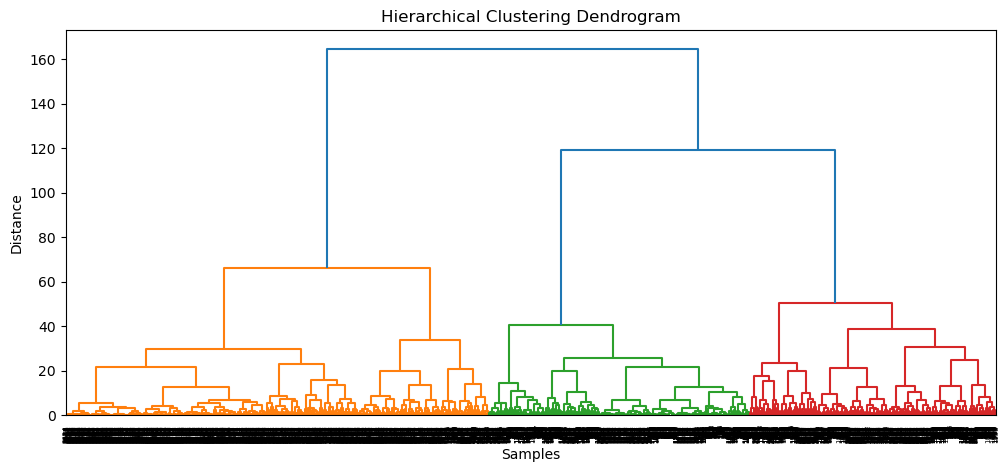

In [41]:
plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [42]:
hier_clusters = fcluster(linkage_matrix, 5, criterion='maxclust')
df1['Hier_Cluster'] = hier_clusters

In [43]:
for eps in [1.5, 2.0, 2.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    clusters = db.fit_predict(df1)
    print(f"DBSCAN with eps={eps} -> Clusters: {set(clusters)}")
    df1[f'DBSCAN_eps{eps}'] = clusters

DBSCAN with eps=1.5 -> Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(-1)}
DBSCAN with eps=2.0 -> Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(-1)}
DBSCAN with eps=2.5 -> Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(-1)}


In [44]:
print(df1[['KMeans_Cluster', 'Hier_Cluster'] + [col for col in df1.columns if 'DBSCAN' in col]].head())

   KMeans_Cluster  Hier_Cluster  DBSCAN_eps1.5  DBSCAN_eps2.0  DBSCAN_eps2.5
0               4             3              0              0              0
1               4             3              0              0              0
2               4             3              0              0              0
3               4             3              0              0              0
4               2             4              1              1              1


In [45]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [46]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df1)

In [47]:
df1['PCA1'] = df_pca[:, 0]
df1['PCA2'] = df_pca[:, 1]

In [49]:
### model can change the optimal score valuer in silhouette value
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    print(f"K={k}, Silhouette={score:.3f}")
    if score > best_score:
        best_score = score
        best_k = k

K=2, Silhouette=0.707
K=3, Silhouette=0.727
K=4, Silhouette=0.663
K=5, Silhouette=0.716
K=6, Silhouette=0.757
K=7, Silhouette=0.752
K=8, Silhouette=0.717
K=9, Silhouette=0.663
K=10, Silhouette=0.672


In [51]:
kmeans = KMeans(n_clusters=3)
cluster = kmeans.fit(df1)
silhouette_score(df1,cluster.labels_)

0.6328568235652025

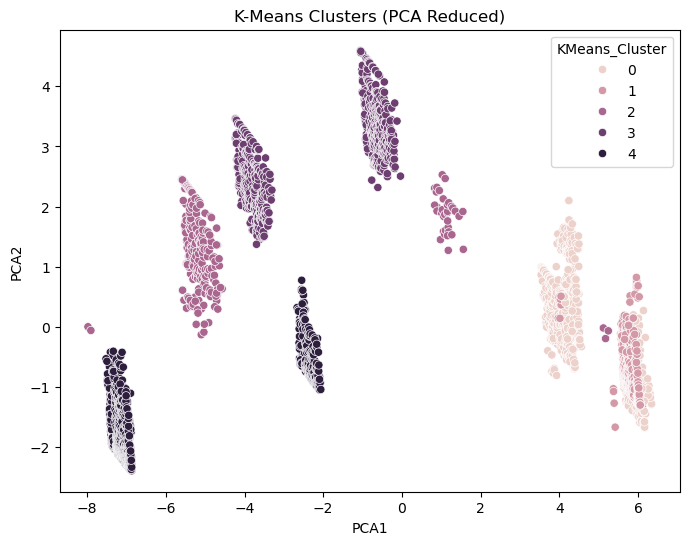

In [52]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2',hue='KMeans_Cluster',data=df1)
plt.title("K-Means Clusters (PCA Reduced)")
plt.show()

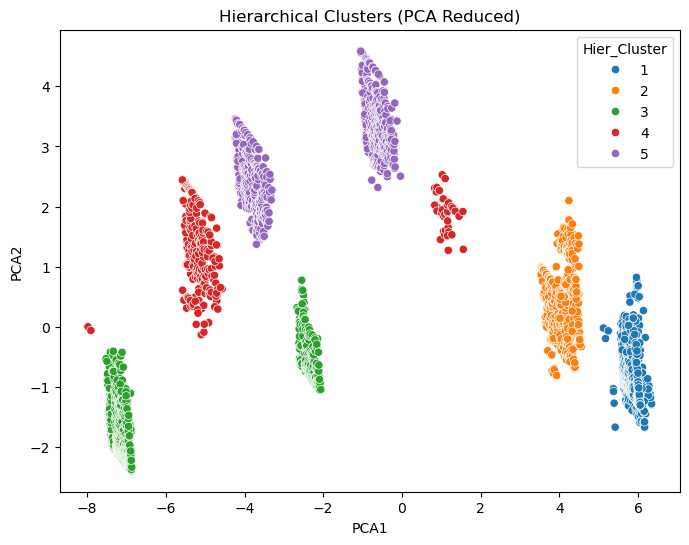

In [53]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Hier_Cluster', palette='tab10', data=df1)
plt.title("Hierarchical Clusters (PCA Reduced)")
plt.show()

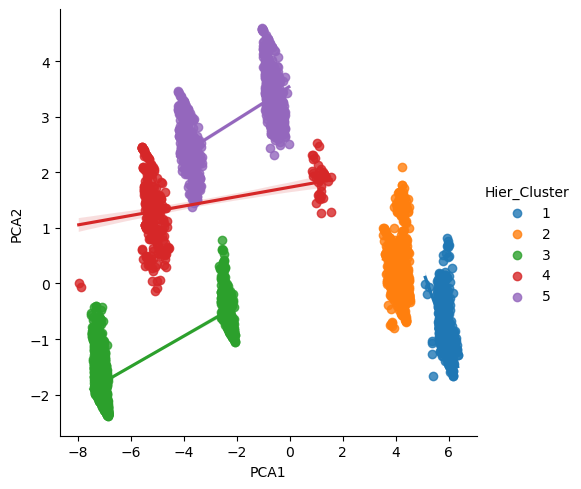

In [57]:
sns.lmplot(x='PCA1', y='PCA2', hue='Hier_Cluster', palette='tab10', data=df1)
plt.show()

In [58]:
inertia = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df1)
    inertia.append(kmeans.inertia_)
print(inertia)

[261302.34889046242, 67947.7206421851, 32487.07329320161, 26647.74471052846, 17688.047648402677, 15279.176538609747, 11611.704943909623, 9149.21876539612, 8502.300209405843, 8498.368773986667]


In [59]:
best_score = -1
best_k = None

In [62]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df1)
    score = silhouette_score(df1,cluster.labels_)
    print(f"K={k}, Silhouette={score:.3f}")
    if score > best_score:
        best_score = score
        best_k = k

K=2, Silhouette=0.633
K=3, Silhouette=0.633
K=4, Silhouette=0.633
K=5, Silhouette=0.633
K=6, Silhouette=0.633
K=7, Silhouette=0.633
K=8, Silhouette=0.633
K=9, Silhouette=0.633
K=10, Silhouette=0.633


In [63]:
kmeans = KMeans(n_clusters=3)
cluster = kmeans.fit(df1)
silhouette_score(df1,cluster.labels_)

0.6227868312202001

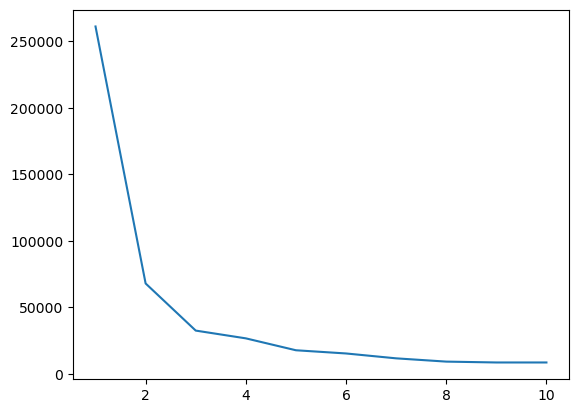

In [64]:
plt.plot(range(1,11),inertia)
plt.show()